# 02: Remove Almost Everything

Executable reduction from Lenia-like spectacle to a one-dimensional binary rule.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BOOK_FIG_DIR = ROOT / "static" / "images" / "books" / "digital-life"
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


In [2]:
def elementary_step(state: np.ndarray, rule: int) -> np.ndarray:
    left = np.roll(state, 1)
    centre = state
    right = np.roll(state, -1)
    neighborhood = (left << 2) | (centre << 1) | right
    return ((rule >> neighborhood) & 1).astype(np.uint8)


def single_seed(width: int) -> np.ndarray:
    state = np.zeros(width, dtype=np.uint8)
    state[width // 2] = 1
    return state


def run_rule(rule: int, width: int, generations: int, initial_state=None) -> np.ndarray:
    state = single_seed(width) if initial_state is None else initial_state.astype(np.uint8).copy()
    history = np.zeros((generations, width), dtype=np.uint8)
    history[0] = state
    for t in range(1, generations):
        state = elementary_step(state, rule)
        history[t] = state
    return history


def show_spacetime(history, title, path=None, figsize=(10, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(history, cmap="binary", interpolation="nearest", aspect="auto", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Space")
    ax.set_ylabel("Time")
    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight")
    plt.show()


In [3]:
EXPERIMENT = {"rule22": 22, "rule30": 30, "width": 181, "generations_rule22": 80, "generations_rule30": 45, "boundary": "periodic"}
EXPERIMENT


{'rule22': 22,
 'rule30': 30,
 'width': 181,
 'generations_rule22': 80,
 'generations_rule30': 45,
 'boundary': 'periodic'}

## Claim being tested

Removing continuous state, 2D geometry, large neighborhoods, and smooth responses does not force all visible organization to disappear.


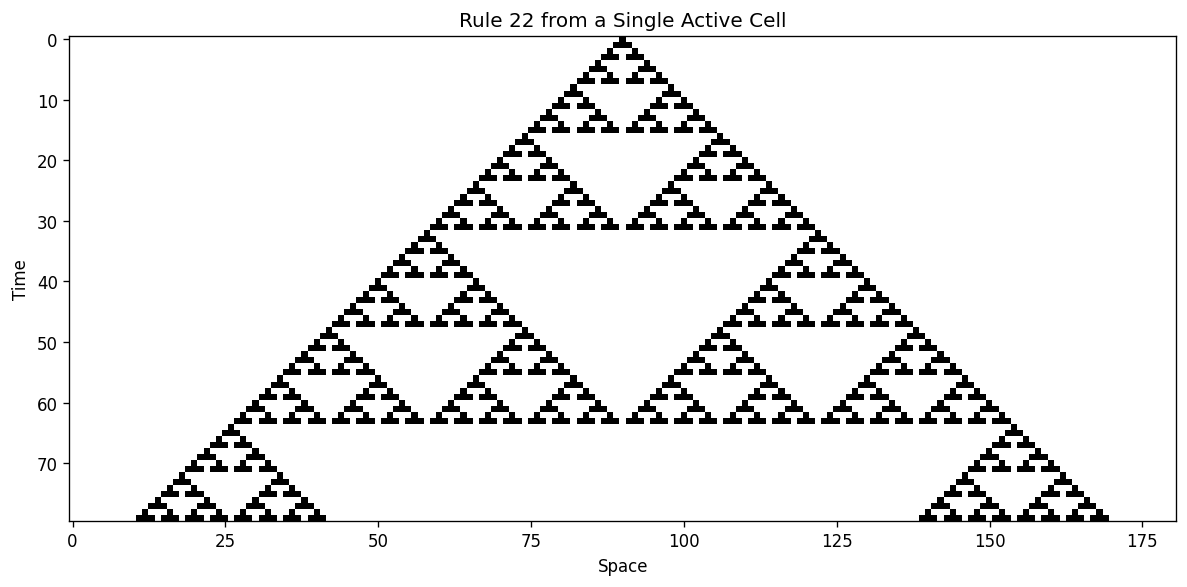

In [4]:
rule22 = run_rule(EXPERIMENT["rule22"], EXPERIMENT["width"], EXPERIMENT["generations_rule22"])
show_spacetime(rule22, "Rule 22 from a Single Active Cell", FIG_DIR / "ch02-rule22-spacetime.png")


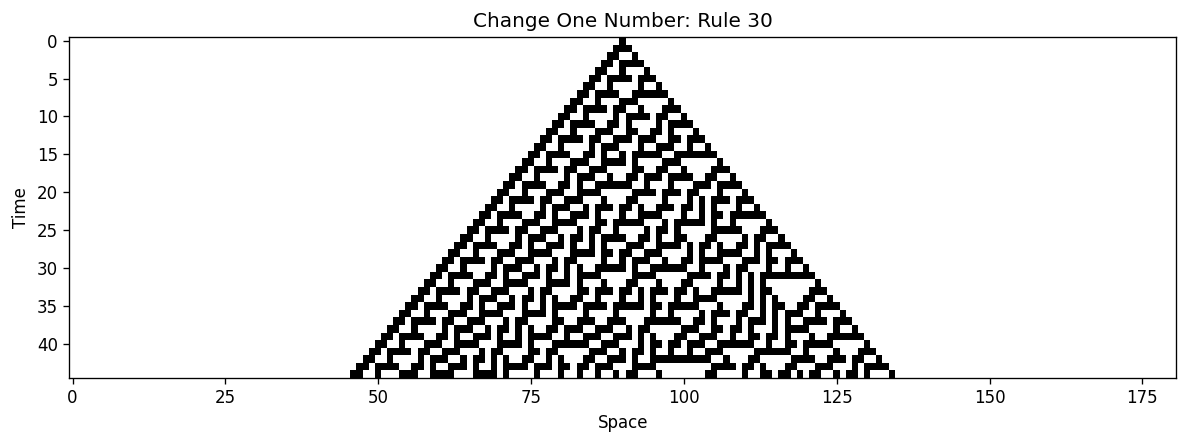

In [5]:
rule30 = run_rule(EXPERIMENT["rule30"], EXPERIMENT["width"], EXPERIMENT["generations_rule30"])
show_spacetime(rule30, "Change One Number: Rule 30", FIG_DIR / "ch02-rule30-teaser.png", figsize=(10, 3.8))


In [6]:
{"rule22_final_active": int(rule22[-1].sum()), "rule30_final_active": int(rule30[-1].sum()), "local_rule_count": 2**8}


{'rule22_final_active': 48, 'rule30_final_active': 38, 'local_rule_count': 256}

## What the evidence supports

The behavior belongs to the whole experimental configuration: rule, initial state, boundary, width, update semantics, and time. The notebook reproduces the chapter's two ECA figures from code.

## What it does not support

It does not establish unpredictability, entities, robustness, or life.

## Provenance

**Book chapter**

`content/books/digital-life/02-remove-almost-everything/index.md`

**Research scripts used**

- `scripts/books/digital-life/ch02_remove_almost_everything.py`

**Book figures reproduced**

- `static/images/books/digital-life/ch02-rule22-spacetime.png`
- `static/images/books/digital-life/ch02-rule30-teaser.png`
